## 2nd major components: Prompts

Prompts are the input instructions or queries given to a model to guide its output.

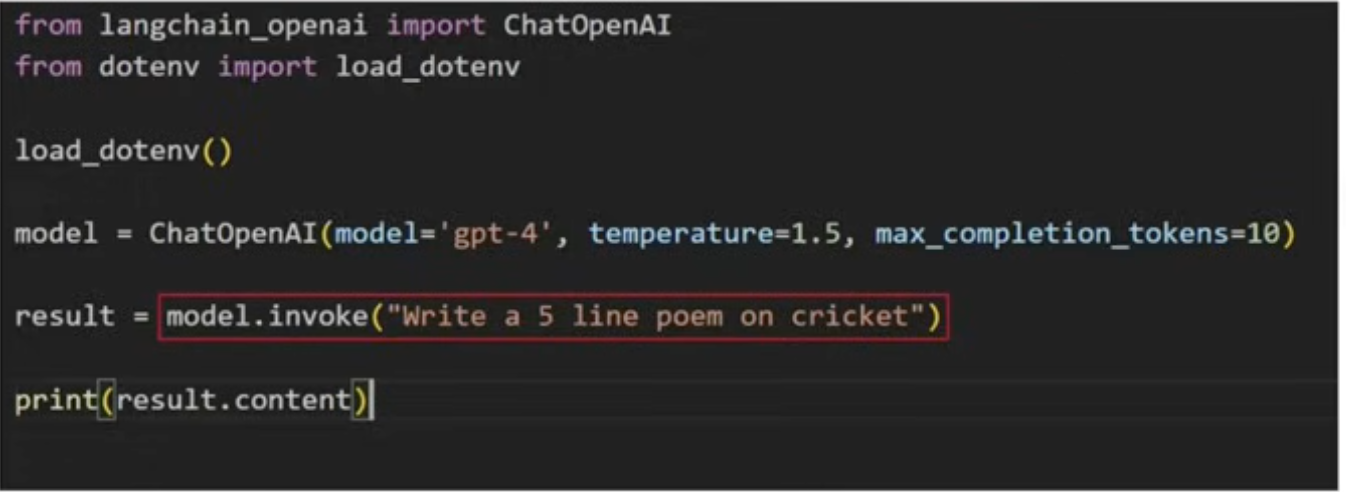

The message you send to LLM is called a prompt

In [ ]:
# User
#  │
#  │ Prompt
#  ▼
# LLM
#  │
#  │ Generated response
#  ▼
# Output



# User:
# "Explain machine learning in simple language."

#              ↓

#           LLM

#              ↓

# "Machine learning is a branch of AI..."

# So a prompt is basically what you tell the model to do.

## Why are prompts important ?

Prompts are so important that LLM output is very sensitive to it. The model's response can change significantly depending on how you phrase the instruction.

Prompt 1: Explain machine learning.

The model might give a technical explanation.

Prompt 2: Explain machine learning to a 10-year-old.

Now the answer will be much simpler.

Prompt 3: Explain machine learning in 3 bullet points.

Now the model will probably produce a short bullet-point answer.


Same model: LLM

Different prompt: Different instructions -> Potentially different output

Therefore: Prompt design is an important part of building an LLM application.

## Types of Prompts:

1- Text Based prompts

2- Multimodal prompts -> Image / video / sound

## The Problem With Hard-Coding the Prompt

result = model.invoke("Write a 5 line poem on cricket")

The above way is not the right way.Suppose you're creating a research assistant.

model.invoke("Summarize the attention is all you need paper")

Now your application can only summarize that particular paper/question.

That's not useful for a real user.

In [ ]:
; Real-World Application

; Imagine you're building:

; ┌──────────────────────────┐
; │    Research Assistant    │
; │                          │
; │  [ User Input Box ]      │
; │                          │
; │       [Summarize]        │
; └──────────────────────────┘

; The user could enter:

; "Summarize the Attention Is All You Need paper."
; or:
; "Explain the methodology of this paper."
; or:
; "What are the limitations of this research?"
; The programmer doesn't know beforehand what the user will type.
; Therefore, you can't hard-code:
; model.invoke("Summarize the attention is all you need paper")

## User Prompt vs Programmer Prompt

There are essentially two sources of instructions.

## Programmer/developer instructions

These are defined by the application developer.

For example:

You are a research assistant. Answer clearly and accurately. Use simple language. User input , This comes dynamically from the user.

For example: Summarize this research paper.

## User input

This comes dynamically from the user.

For example: Summarize this research paper.

In [ ]:
# Developer instructions
# +
# User input
# ↓
# Final prompt
# ↓
# LLM

## 2 Types of prompts:

1-Static 

2-Dynamic

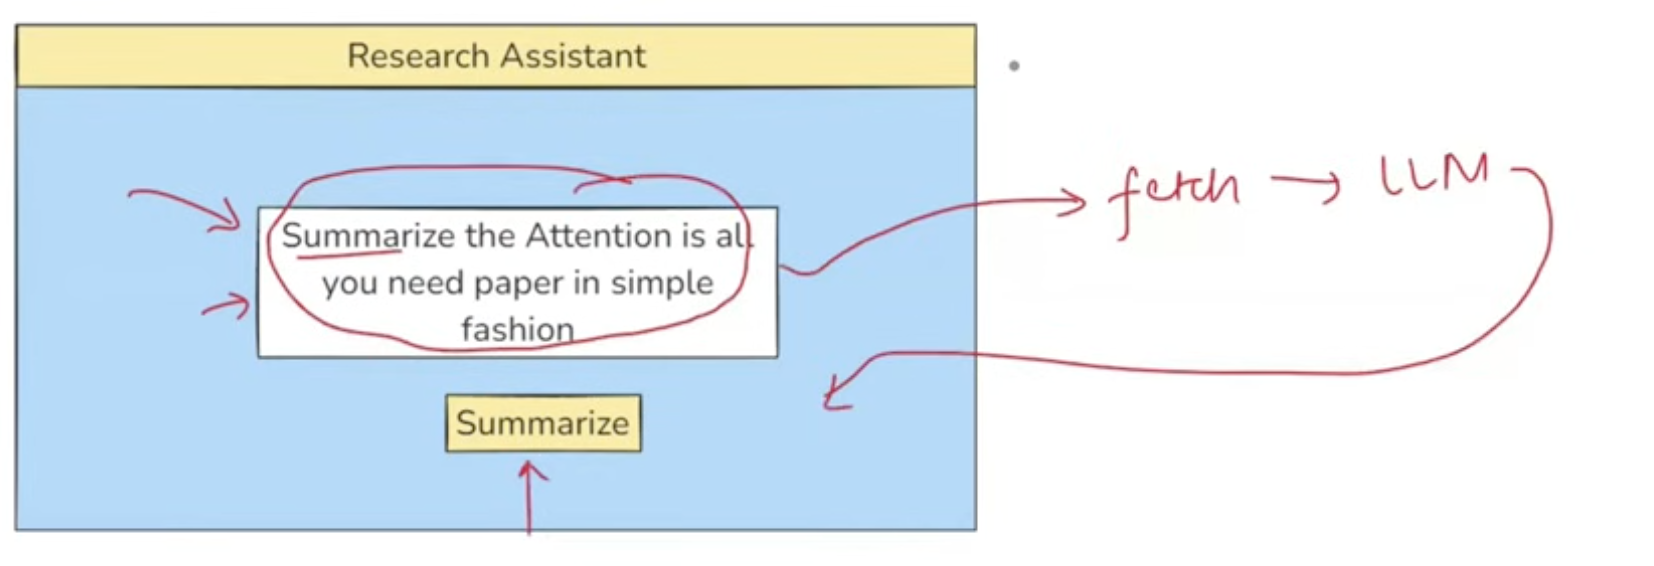

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import streamlit as st
load_dotenv()

True

In [5]:
!pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.2/111.2 MB 20.7 MB/s  0:00:05m0:00:0100:01
  Attempting uninstall: torch
    Found existing installation: torch 2.12.1
    Uninstalling torch-2.12.1:━━━━━━━━━━━━━━━━━━ 0/2 [torch]
      Successfully uninstalled torch-2.12.1━ 0/2 [torch]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchvision] [torchvision]


In [9]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

model = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    google_api_key=os.getenv("GOOGLE_API_KEY")
)

In [10]:
%%writefile app.py

import streamlit as st
st.header("Research Tool")
user_input = st.text_input("Enter your prompt")
## This is called static prompt
if st.button("Summarize"):
    result=model.invoke(user_input)
    st.write(result.content)

Overwriting app.py


In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    google_api_key=os.getenv("GOOGLE_API_KEY")
)
response = model.invoke("Hello")
print(response.content[0]['text'])

Hello! How can I help you today?


In [ ]:
# Don't think:  Prompt = just a question.
# A prompt can contain:
# Role/instructions +  Context  +  Examples  + User request + Output requirements

## Static Prompt:

the application asks the user to write the entire prompt themselves.

For example, your UI has just one text box:

In [ ]:
# ┌──────────────────────────────────────┐
# │ Enter your prompt:                   │
# │                                      │
# │ Summarize this research paper...     │
# │                                      │
# └──────────────────────────────────────┘

# Then you send exactly what the user typed:
# result = model.invoke(user_prompt)

## Problem:

users may write: summarize this paper or: make it short or: explain everything or give unclear/incomplete instructions.

The LLM then has to figure out what the user actually wants. So the output can become inconsistent.

## Dynamic Prompt

Instead of asking the user to write the whole prompt, the programmer creates a template beforehand.

Dynamic prompt: ye prompt humne pehle se hi likh rakha hai, key ki values hum user se mangwa rahe hain.

Example:

Please summarize the research paper titled "{paper_input}"
with the following specifications:

Explanation style: {style_input}

Explanation length: {length_input}

{paper_input},{style_input},{length_input} are are variables/placeholders. The programmer has already designed the structure.The user only provides the values.

The user doesn't have to know how to write a good prompt. The application does that for them.

## Prompt Template

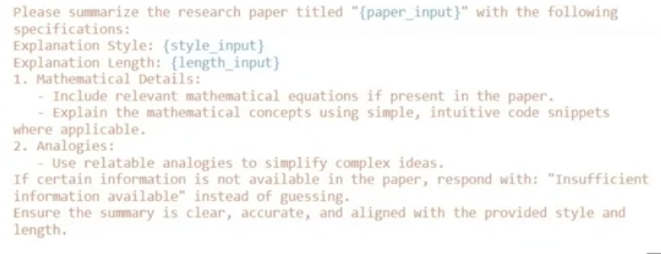

In [25]:
%%writefile app2.py

import os
import streamlit as st

from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate


# Load environment variables
load_dotenv()


# Create Gemini model
model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    api_key=os.getenv("GOOGLE_API_KEY")
)


# UI
st.header("Researcher Tool")


# 1. Research paper
paper_input = st.selectbox(
    "Select Research Paper name",
    [
        "Attention is all you need",
        "BERT: Pre-training of Deep Bidirectional Transformers",
        "GPT-3: Language models are Few-Shot Learners",
        "Diffusion Models beat GANs on Image Synthesis"
    ]
)


# 2. Explanation style
style_input = st.selectbox(
    "Select Explanation style",
    [
        "Beginner-Friendly",
        "Technical",
        "Code-Oriented",
        "Mathematical"
    ]
)


# 3. Explanation length
length_input = st.selectbox(
    "Select Explanation Length",
    [
        "Short (1-2 Paragraphs)",
        "Medium (3-5 Paragraphs)",
        "Long (Detailed Explanation)"
    ]
)


# Prompt template
template = PromptTemplate(
    template="""
Please summarize the research paper titled "{paper_input}"
with the following specifications:

Explanation Style: {style_input}
Explanation Length: {length_input}

1. Mathematical Details:
- Include relevant mathematical equations if present in the paper.
- Explain the mathematical concepts using simple, intuitive
  code snippets where applicable.

2. Analogies:
- Use relatable analogies to simplify complex ideas.

If certain information is not available in the paper,
respond with "Insufficient information available"
instead of guessing.

Ensure the summary is clear, accurate, and aligned
with the provided style and length.
""",
    input_variables=[
        "paper_input",
        "style_input",
        "length_input"
    ]
)


# Fill placeholders
prompt = template.invoke({
    "paper_input": paper_input,
    "style_input": style_input,
    "length_input": length_input
})


# Generate response
if st.button("Summarize"):
    result = model.invoke(prompt)
    st.write(result.content[0]['text'])

Overwriting app2.py


In [ ]:
# Streamlit UI
#      │
#      ├── Select Research Paper
#      ├── Select Explanation Style
#      └── Select Explanation Length
#               │
#               ↓
#        PromptTemplate
#               │
#        Fill placeholders
#               │
#               ↓
#          Final Prompt
#               │
#               ↓
#        Gemini Chat Model
#               │
#               ↓
#           Summary

## Prompt Template

A PromptTemplate in langchain is a structured way to create prompts dynamically by inserting variables into a predefined template. Instead of hardcoding prompts, PromptTemplate allows you to define placeholder that can be filled in at runtime with different inputs.

This makes it reusable, flexible and easy to manage. Especially, when working with dynamic user inputs or automated workflows.

## Why it is better than f strings ?

1- Default Validation

In [26]:

import os
import streamlit as st

from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate


load_dotenv()


model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    api_key=os.getenv("GOOGLE_API_KEY")
)


st.header("Researcher Tool")


paper_input = st.selectbox(
    "Select Research Paper name",
    [
        "Attention is all you need",
        "BERT: Pre-training of Deep Bidirectional Transformers",
        "GPT-3: Language models are Few-Shot Learners",
        "Diffusion Models beat GANs on Image Synthesis"
    ]
)


style_input = st.selectbox(
    "Select Explanation style",
    [
        "Beginner-Friendly",
        "Technical",
        "Code-Oriented",
        "Mathematical"
    ]
)


length_input = st.selectbox(
    "Select Explanation Length",
    [
        "Short (1-2 Paragraphs)",
        "Medium (3-5 Paragraphs)",
        "Long (Detailed Explanation)"
    ]
)


template = PromptTemplate(
    template="""
Please summarize the research paper titled "{paper_input}"
with the following specifications:

Explanation Style: {style_input}
Explanation Length: {length_input}

1. Mathematical Details:
- Include relevant mathematical equations if present in the paper.
- Explain the mathematical concepts using simple, intuitive
  code snippets where applicable.

2. Analogies:
- Use relatable analogies to simplify complex ideas.

If certain information is not available in the paper,
respond with "Insufficient information available"
instead of guessing.

Ensure the summary is clear, accurate, and aligned
with the provided style and length.
""",
    input_variables=[
        "paper_input",
        "style_input",
    ], ## Suppose you forgot to add length input in input_variables

validate_template=True 
## checks if all the placeholders are present in input_variables or not

## If not present then it will trigger error 
)


prompt = template.invoke({
    "paper_input": paper_input,
    "style_input": style_input,
    "length_input": length_input
})


# Generate response
if st.button("Summarize"):
    result = model.invoke(prompt)
    st.write(result.content[0]['text'])

## the error will show missing parameter


2026-08-10 17:04:06.873 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-10 17:04:06.956 
  command:

    streamlit run /opt/anaconda3/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-08-10 17:04:06.956 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-10 17:04:06.956 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-10 17:04:06.957 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-10 17:04:06.958 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-10 17:04:06.959 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-10 17:04:06.960 Thread 'MainThread': m

ValidationError: 1 validation error for PromptTemplate
  Value error, Invalid prompt schema; check for mismatched or missing input parameters from ['paper_input', 'style_input']. [type=value_error, input_value={'template': '\nPlease su...'partial_variables': {}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error

In [29]:
## this won't give error in runtime, in development phase only.. I mean in server we get to see the error before that.
## If we add extra placeholder then also it gives error..

2- Reusable

We can reuse the prompt template. We can save our Template as a json file and whenever it is needed, we can load it and run it.

In [32]:
template = PromptTemplate(
    name='research agent',
    template="""
Please summarize the research paper titled "{paper_input}"
with the following specifications:

Explanation Style: {style_input}
Explanation Length: {length_input}

1. Mathematical Details:
- Include relevant mathematical equations if present in the paper.
- Explain the mathematical concepts using simple, intuitive
  code snippets where applicable.

2. Analogies:
- Use relatable analogies to simplify complex ideas.

If certain information is not available in the paper,
respond with "Insufficient information available"
instead of guessing.

Ensure the summary is clear, accurate, and aligned
with the provided style and length.
""",
    input_variables=[
        "paper_input",
        "style_input",
        "length_input"
    ],
    validate_template=True
)

template.save('template.json')

In [33]:
from langchain_core.prompts import load_prompt

temp=load_prompt('template.json')
temp

/var/folders/gg/f1jqwyw902s1lt078gd0wfdm0000gn/T/ipykernel_22978/3930490426.py:3: LangChainDeprecationWarning: The function `load_prompt` was deprecated in LangChain 1.2.21 and will be removed in 2.0.0. Use `Use `dumpd`/`dumps` from `langchain_core.load` to serialize prompts and `load`/`loads` to deserialize them.` instead.
  temp=load_prompt('template.json')


PromptTemplate(name='research agent', input_variables=['length_input', 'paper_input', 'style_input'], input_types={}, partial_variables={}, template='\nPlease summarize the research paper titled "{paper_input}"\nwith the following specifications:\n\nExplanation Style: {style_input}\nExplanation Length: {length_input}\n\n1. Mathematical Details:\n- Include relevant mathematical equations if present in the paper.\n- Explain the mathematical concepts using simple, intuitive\n  code snippets where applicable.\n\n2. Analogies:\n- Use relatable analogies to simplify complex ideas.\n\nIf certain information is not available in the paper,\nrespond with "Insufficient information available"\ninstead of guessing.\n\nEnsure the summary is clear, accurate, and aligned\nwith the provided style and length.\n', validate_template=True)

In [ ]:
## Template can lie anywhere but we can load it in our file



## PromptTemplate is deeply coupled with ecosystem of langchain.


## Problem: We are invoking two times

first time we invoke template and then we invoke model

prompt = template.invoke({
    "paper_input": paper_input,
    "style_input": style_input,
    "length_input": length_input
})


# Generate response
if st.button("Summarize"):
    result = model.invoke(prompt)
    st.write(result.content[0]['text'])


In [ ]:
prompt=template.invoke( ## 1st invoke
    {
        "paper_input":paper_input,
        "style_input":style_input,
        "length_input":length_input
    }
)

if st.button("summarize"):
    result=model.invoke(prompt) ## 2nd invoke
    st.write(result.content)

In [ ]:
# We can invoke them collectively using chain
# lets not invoke template


template=PromptTemplate(
    template=
    """
Please summarize the research paper titled "{paper_input}"
with the following specifications:

Explanation Style: {style_input}
Explanation Length: {length_input}

1. Mathematical Details:
- Include relevant mathematical equations if present in the paper.
- Explain the mathematical concepts using simple, intuitive
  code snippets where applicable.

2. Analogies:
- Use relatable analogies to simplify complex ideas.

If certain information is not available in the paper,
respond with "Insufficient information available"
instead of guessing.

Ensure the summary is clear, accurate, and aligned
with the provided style and length.
""",

input_variables=
[ 'page_input','style_input','length_input'
],
validate_template=True,
name='Research Tool'

)



if st.button("submit"):
    chain= template | model ## create chain of template and model 
    result=chain.invoke(
        {
            'paper_input':paper_input,
            'style_input':style_input,
            'length_input':length_input
        }
    )

    st.write(result.content)

## Chatbot Application



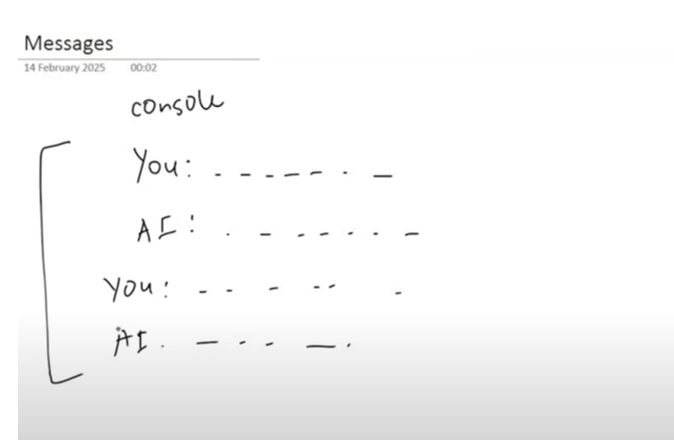


We won't create GUI for chatbot, we will use our own console

In [35]:
from langchain_google_genai import GoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()

# Create Gemini model
model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    api_key=os.getenv("GOOGLE_API_KEY")
)


while True:
    user_input=input("You: ")
    if user_input=='exit':
        break

    result=model.invoke(user_input)
    print("AI: ",result.content)

## Problem: It doesn't remember old conversation


True

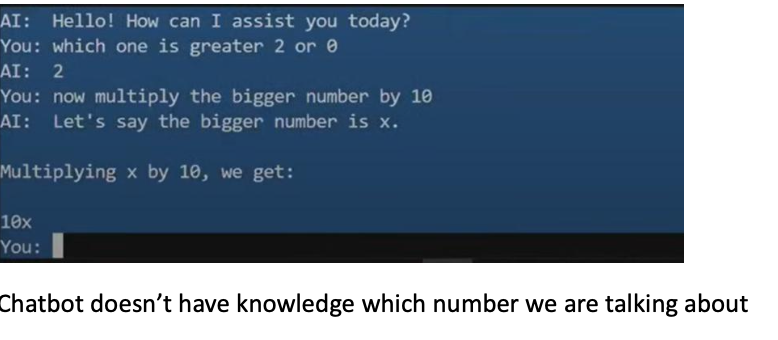

Chatbot doesn’t have context..it couldn’t remember previous messages.
Therefore we need to maintain chat history..then we send whole history to llm therefore we do
some changes in our code

In [ ]:
from langchain_google_genai import GoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv(override=True)
chat_history=[]
# Create Gemini model
model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    api_key=os.getenv("GOOGLE_API_KEY"),
    vertexai=False
)


while True:
    user_input=input("You: ")
    chat_history.append(user_input)
    if user_input=='exit':
        break

    result=model.invoke(chat_history)
    chat_history.append(result.content)
    print("AI: ",result.content)

print(chat_history)

## Now it remembers old conversation

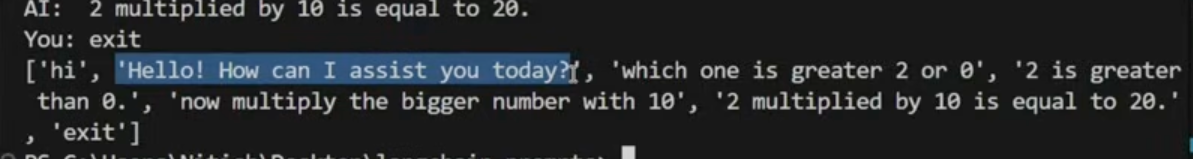

Problem: list is not shown individually like You: hi then AI: Hello! how can i assist you today? 

In [44]:
# Therefore Ideally we should maintain a dictionary like this:

# {
#     'User':----------,
#     'AI':------------,
#     'User':----------- etc
# }

## I want a dictionary instead of a list

## Langchain has built in classes for those problems

## Types of messages in langchain

1-System message: You write this message in the beginning of the conversation 
Example: you are a helpful assistant answer all my queries patiently

2-Human message: The message the user sends

3-AI message: The message the LLM responds back to user query

In [ ]:
from langchain_core.messages import SystemMessage,HumanMessage,AIMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()


model=ChatGoogleGenerativeAI()

messages=[
    SystemMessage(content='You are a helpful AI Assistant'),
    HumanMessage(content='Tell me about Langchain')
]

result=model.invoke(messages)

messages.append(AIMessage(content=result.content))
print(messages)

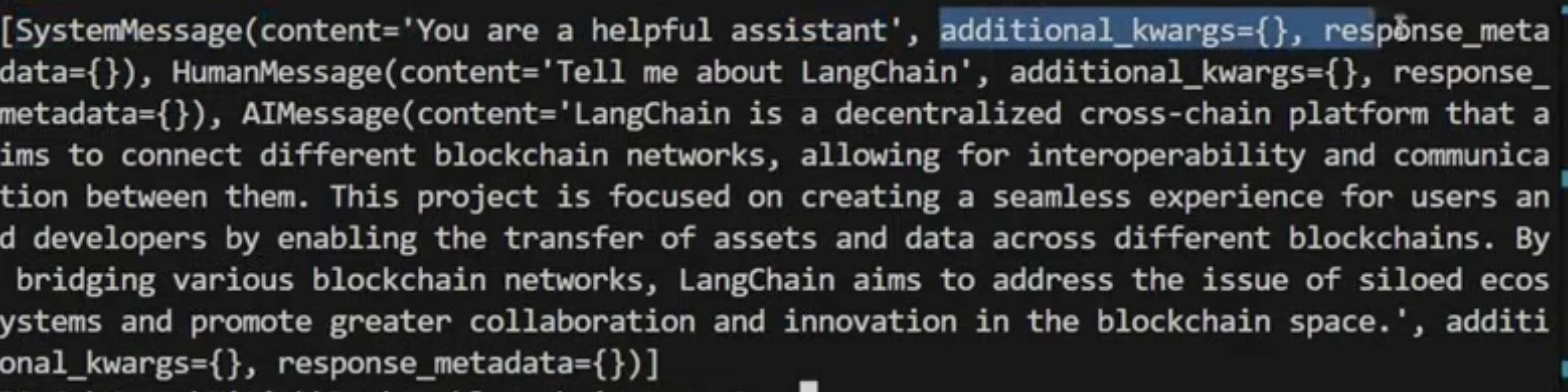

In [ ]:
from langchain_google_genai import GoogleGenerativeAI
from dotenv import load_dotenv
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage

load_dotenv(override=True)

chat_history=[
    SystemMessage(content='You are a helpful AI Assistant')
]
# Create Gemini model
model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    api_key=os.getenv("GOOGLE_API_KEY"),
    vertexai=False
)


while True:
    user_input=input("You: ")
    user_input=HumanMessage(content=user_input)
    chat_history.append(user_input)
    if user_input=='exit':
        break

    result=model.invoke(chat_history)
    result=AIMessage(content=result)
    chat_history.append(result.content)
    print("AI: ",result.content)

print(chat_history)



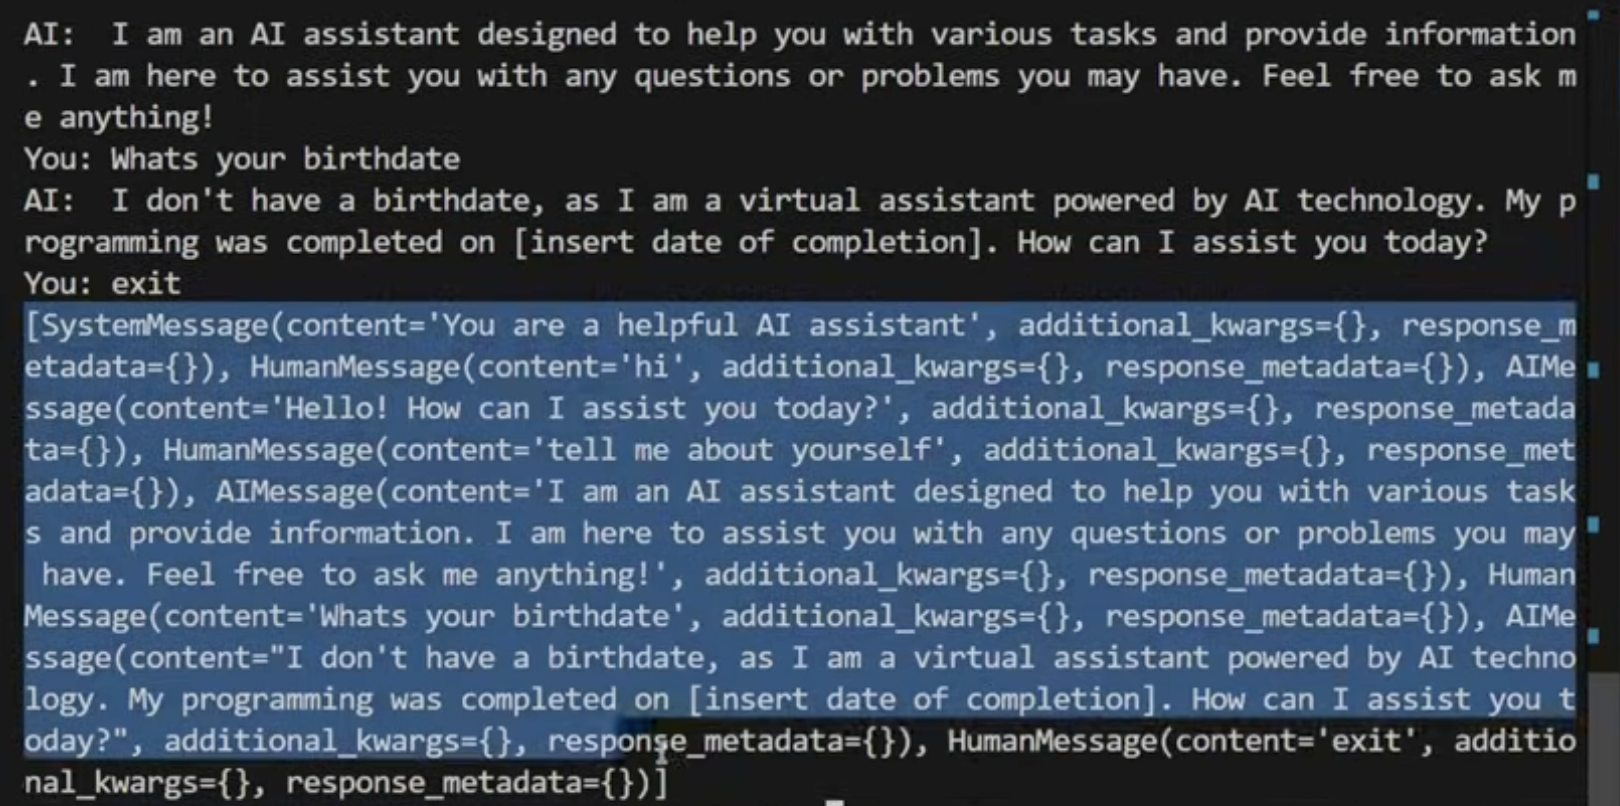

## Dynamic List of Messages - Chat Prompt Template

We can create a prompt where system message and human message both are dynamic

Example:

System Message: You are a helpful {domain} expert 

Human Message: Explain about {topic}

In [48]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage,HumanMessage,AIMessage

chat_template=ChatPromptTemplate([
    SystemMessage(content='You are a helpful {Domain} expert'),
    HumanMessage(content='Explain in simple terms, what is {topic}')
]
)

prompt=chat_template.invoke({'Domain':'cricket','topic':'six'})
## this doesn't get filled in langchain

print(prompt)

## you need to write in a different way to make this code work

## Explain in simple terms, what is {topic} so we get {topic} instead of cricket 

messages=[SystemMessage(content='You are a helpful {Domain} expert', additional_kwargs={}, response_metadata={}), HumanMessage(content='Explain in simple terms, what is {topic}', additional_kwargs={}, response_metadata={})]


In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage,HumanMessage,AIMessage

chat_template=ChatPromptTemplate([
    SystemMessage(content='You are a helpful {Domain} expert'),
    HumanMessage(content='Explain in simple terms, what is {topic}')
]
)

prompt=chat_template.invoke({'Domain':'cricket','topic':'six'})
## this doesn't get filled in langchain

print(prompt)

## you need to write in a different way to make this code work 

In [49]:
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage
from langchain_core.prompts import ChatPromptTemplate

chat_template=ChatPromptTemplate([
    ('system','you are a helpful {domain} assistant'),
    ('human','Explain in simple terms, what is {topic}')
]
)
prompt=chat_template.invoke({'domain':'cricket','topic':'cricket'})

print(prompt)

messages=[SystemMessage(content='you are a helpful cricket assistant', additional_kwargs={}, response_metadata={}), HumanMessage(content='Explain in simple terms, what is cricket', additional_kwargs={}, response_metadata={})]


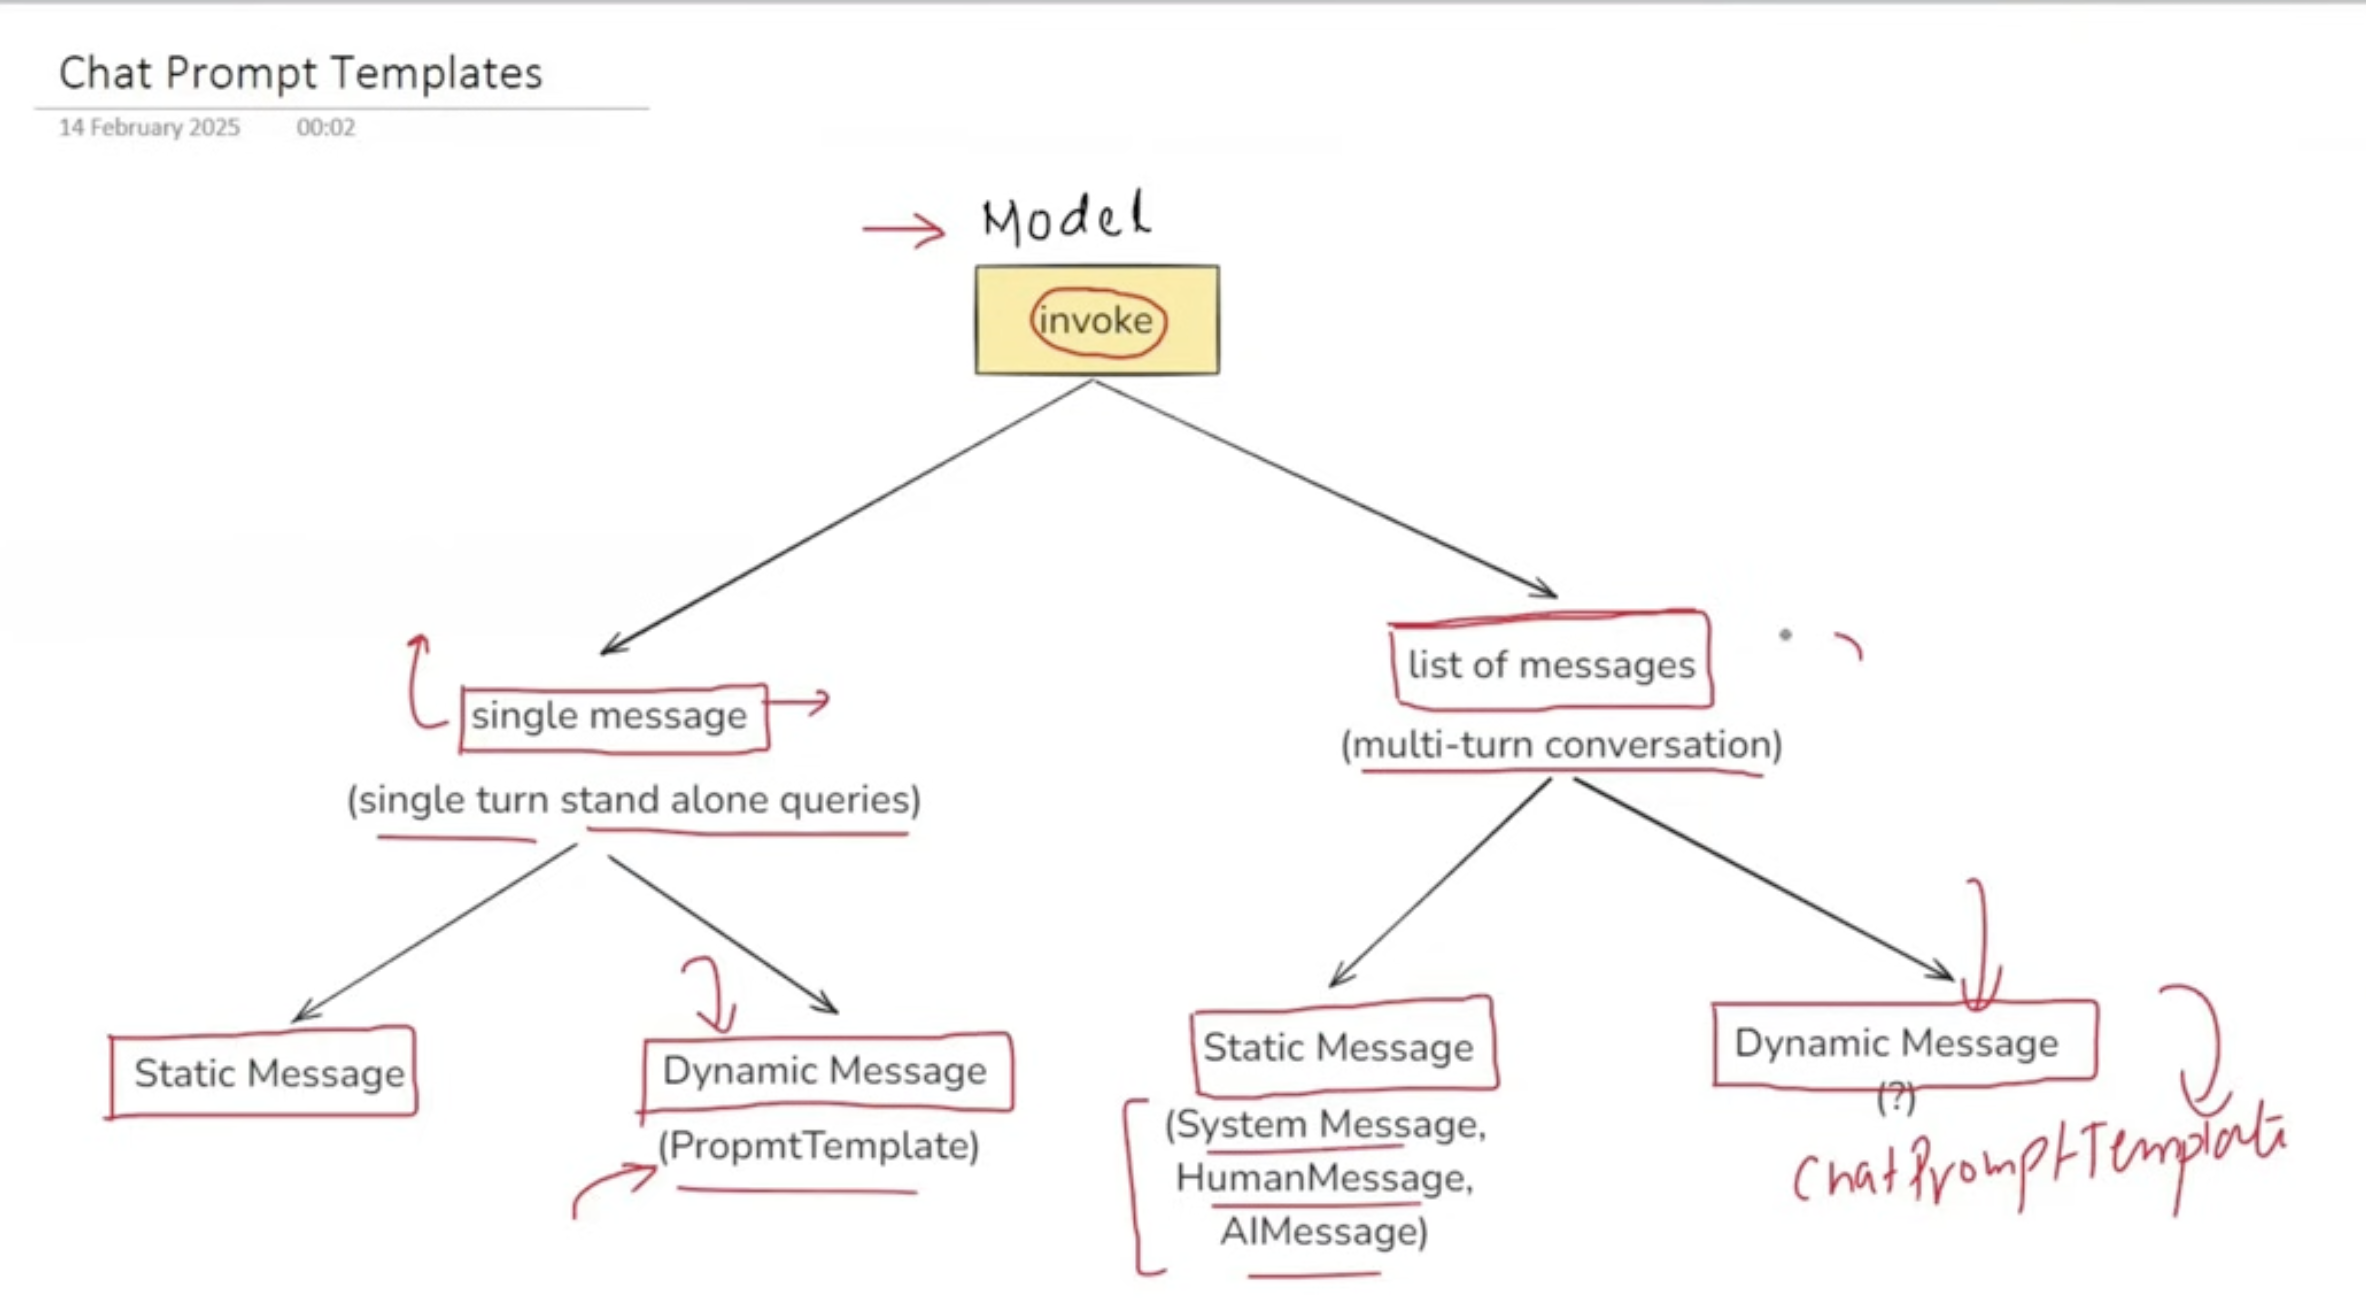

## Message Placeholder

A MessagesPlaceholder in LangChain is a special placeholder used inside a ChatPromptTemplate to dynamically insert chat history or a list of messages at runtime.



## Problem 1:

Suppose your chatbot has this conversation:

User: I want a refund.

AI: Your refund has been generated.
    You will receive it in 3-4 days.

User: What is the status of my refund?

When the user asks:

"What is the status of my refund?"

The LLM needs to know what "my refund" refers to.

The latest message alone is: What is the status of my refund?

Without previous conversation, the model may not know:

Which refund? Was a refund already generated? When was it supposed to arrive?

So we need to send the previous conversation along with the latest message.

## Solution: Sending a list of messages

You've already learned that an LLM can receive a list of messages.

Conceptually:

chat_history = [
    HumanMessage(content="I want a refund."),
    AIMessage(content="Your refund has been generated. You will receive it in 3-4 days."),
    HumanMessage(content="What is the status of my refund?")
]

model.invoke(chat_history)

The LLM gets the entire conversation.

So far, so good.

## Problem 2: Imagine a real Amazon chatbot.

A conversation could become:

User: I ordered a phone.

AI: Okay.

User: It arrived damaged.

AI: I'm sorry.

User: I want a refund.

AI: Your refund has been generated.

User: When will I receive it?

AI: 3-4 days.

User: What about my previous order?

AI: ...

User: Actually, I have another problem.

AI: ...

The number of messages keeps increasing.

You can't manually write:

HumanMessage(...),AIMessage(...),HumanMessage(...),AIMessage(...)... every time.

You need something dynamic. That's where MessagesPlaceholder comes in.

There is maintaince of chat history and store it in database now whenever new chat happens, chat history from database is loaded

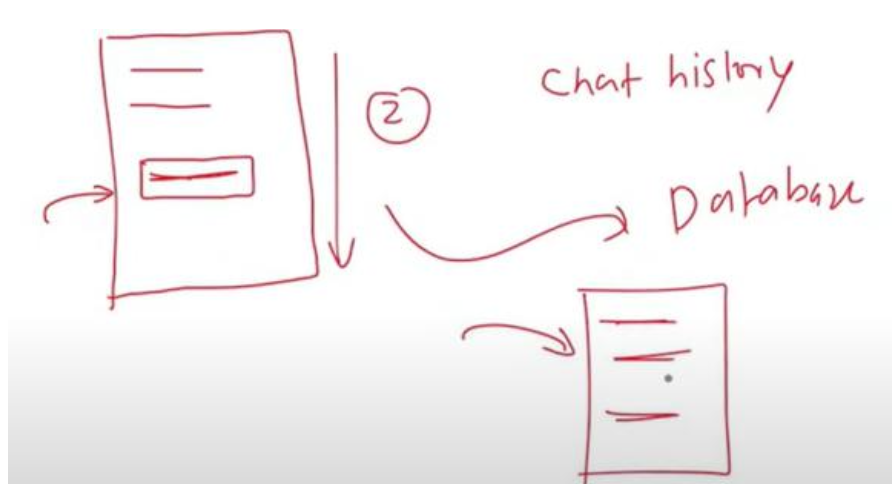

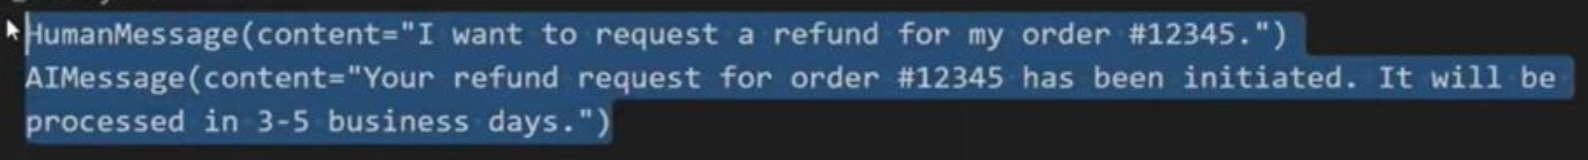

Spse we store this chat history in a text file. Chat is ended and we store it in text file. Next day customers asks where is my refund? For chatbot to answer this, it needs a context of previous messages. 

Till now we have seen we can send a list of messages to a llm and to make it dynamic we studied chatprompt template and if you want to add a list of messages between those two we use message placeholders for that.

In [58]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage


## Chat template
chat_template=ChatPromptTemplate([
    ('system','You are a helpful customer support agent'),

     MessagesPlaceholder(variable_name='chat_history'),
     ## past messages between ai and customer saved in chat history 
     
    ('human', '{query}')
]
)
chat_history=[]
## Load chat history
with open('chat_history.txt') as f:
    chat_history=f.readlines()


print(chat_history)


## create a prompt
prompt=chat_template.invoke({'chat_history':chat_history,'query':'Where is my Refund?'})
print(prompt)

["HumanMessage(content='I want to request a refund for my order #12345'),\n", "AIMessage(content='Your refund requests for the order #12345 has been initiated,\n", 'it will be processed in 3-5 business days)']
messages=[SystemMessage(content='You are a helpful customer support agent', additional_kwargs={}, response_metadata={}), HumanMessage(content="HumanMessage(content='I want to request a refund for my order #12345'),\n", additional_kwargs={}, response_metadata={}), HumanMessage(content="AIMessage(content='Your refund requests for the order #12345 has been initiated,\n", additional_kwargs={}, response_metadata={}), HumanMessage(content='it will be processed in 3-5 business days)', additional_kwargs={}, response_metadata={}), HumanMessage(content='Where is my Refund?', additional_kwargs={}, response_metadata={})]
